In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
data = {
    "name": ["Alice","Bob","Charlie","Diana","Eve","Frank","Grace","Henry","Iris","Jack","Karen","Liam","Mia","Noah","Olivia"],
    "math": [88,42,75,95,38,60,55,82,70,30,65,48,91,58,78],
    "science": [92,55,70,98,42,65,48,79,74,35,60,52,94,62,75],
    "english": [76,48,80,91,50,72,44,85,68,40,70,44,88,55,82],
    "history": [80,50,68,89,45,58,52,77,65,28,62,55,92,60,70],
    "pe": [95,60,88,97,55,70,62,90,78,45,75,58,96,68,85],
    "attendance_pct": [92,65,85,98,58,78,60,88,80,50,72,62,95,70,84],
    "study_hours_per_day": [4.5,1.2,3.0,6.0,0.8,2.5,1.5,4.0,3.5,0.5,2.8,1.8,5.5,2.0,3.8],
    "passed": [1,0,1,1,0,1,0,1,1,0,1,0,1,0,1]
}

df = pd.DataFrame(data)

In [34]:
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [35]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Shape: (15, 9)

Data Types:
 name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [36]:
df.describe()

,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [37]:
df['passed'].value_counts()

,count
passed,
1,9
0,6


In [38]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("Pass Students Average:\n")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nFail Students Average:\n")
print(df[df['passed'] == 0][subject_cols].mean())

Pass Students Average:

math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Fail Students Average:

math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [39]:
# Finding average marks for each student to identify top performer
df['avg_temp'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['avg_temp'].idxmax()]

print("Top Student:\n", top_student[['name', 'avg_temp']])

Top Student:
 name        Diana
avg_temp     94.0
Name: 3, dtype: object


In [40]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

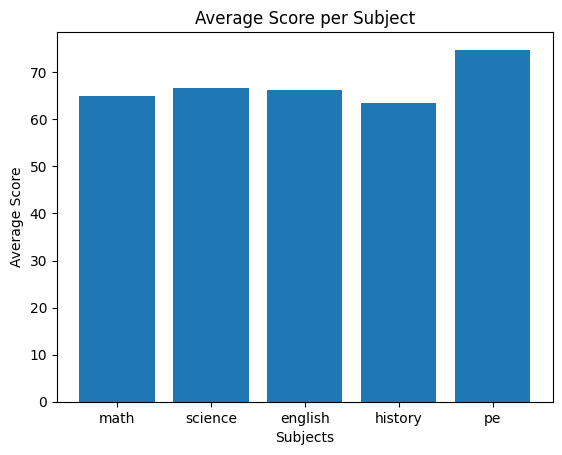

In [41]:
avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(avg_scores.index, avg_scores.values)

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()

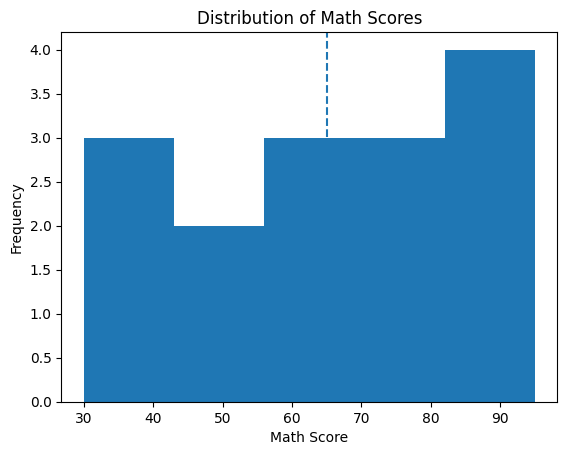

In [42]:
plt.figure()

plt.hist(df['math'], bins=5)

mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed')

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.savefig("plot2_hist.png")
plt.show()

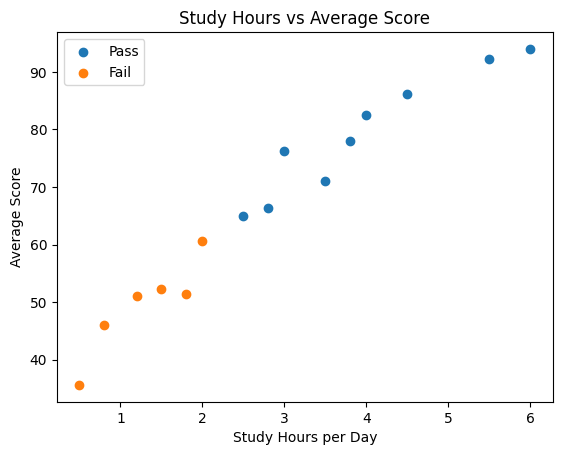

In [43]:
plt.figure()

pass_students = df[df['passed'] == 1]
fail_students = df[df['passed'] == 0]

plt.scatter(pass_students['study_hours_per_day'], pass_students['avg_score'], label="Pass")
plt.scatter(fail_students['study_hours_per_day'], fail_students['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")

plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

/tmp/ipykernel_7380/1680909193.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


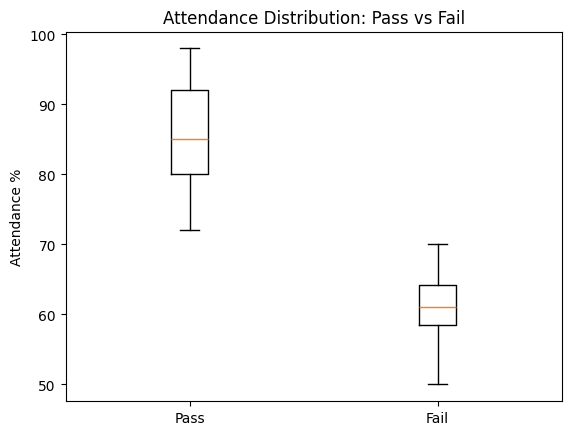

In [44]:
pass_attendance = df[df['passed']==1]['attendance_pct']
fail_attendance = df[df['passed']==0]['attendance_pct']

plt.figure()

plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution: Pass vs Fail")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()

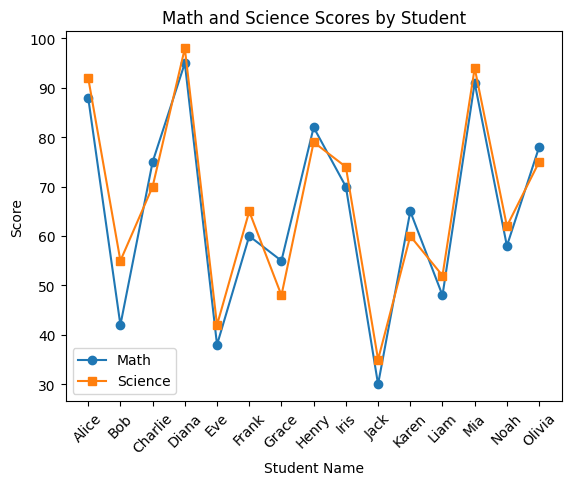

In [45]:
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')

plt.title("Math and Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")

plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

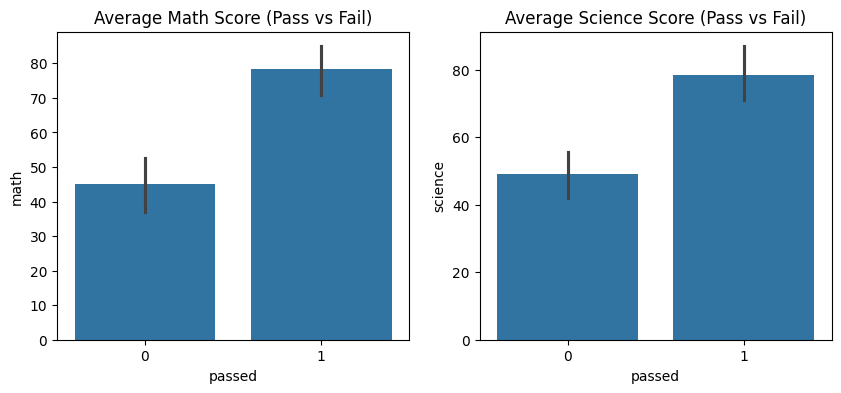

In [46]:
# Seaborn was easier to use for statistical plots and gives better default styling.
plt.figure(figsize=(10,4))

# subplot 1 → Math
plt.subplot(1,2,1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Average Math Score (Pass vs Fail)")

# subplot 2 → Science
plt.subplot(1,2,2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Average Science Score (Pass vs Fail)")

plt.savefig("plot6_seaborn_bar.png")
plt.show()

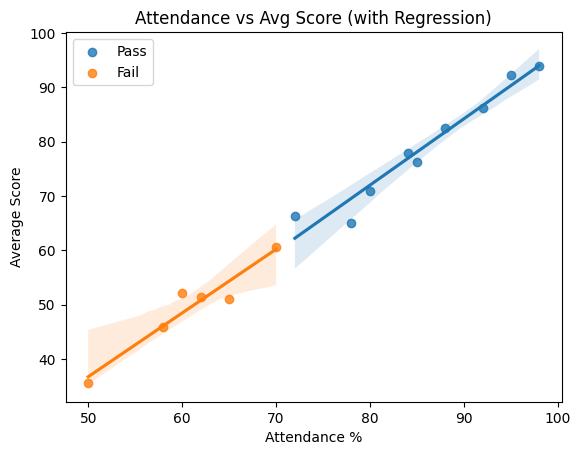

In [47]:
plt.figure()

# Pass students
sns.regplot(
    data=df[df['passed']==1],
    x='attendance_pct',
    y='avg_score',
    label='Pass'
)

# Fail students
sns.regplot(
    data=df[df['passed']==0],
    x='attendance_pct',
    y='avg_score',
    label='Fail'
)

plt.title("Attendance vs Avg Score (with Regression)")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")

plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [49]:
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

In [53]:
train_pred = model.predict(X_train_scaled)

print("Training Accuracy:", accuracy_score(y_train, train_pred))

Training Accuracy: 1.0


In [54]:
y_pred = model.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 1.0


In [55]:
test_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(test_names, y_test, y_pred):
    result = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} → {result}")

Jack: Actual=0, Predicted=0 → ✅ Correct
Liam: Actual=0, Predicted=0 → ✅ Correct
Alice: Actual=1, Predicted=1 → ✅ Correct


In [56]:
coefficients = model.coef_[0]

features = X.columns

feature_importance = list(zip(features, coefficients))

# sort by absolute value
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

for feature, coef in feature_importance:
    print(feature, ":", coef)

english : 0.8125127982724648
attendance_pct : 0.521876340433209
study_hours_per_day : 0.4844326627100155
pe : 0.47497406284967797
math : 0.43794393086873595
science : 0.3230097624690249
history : 0.26292892629062437


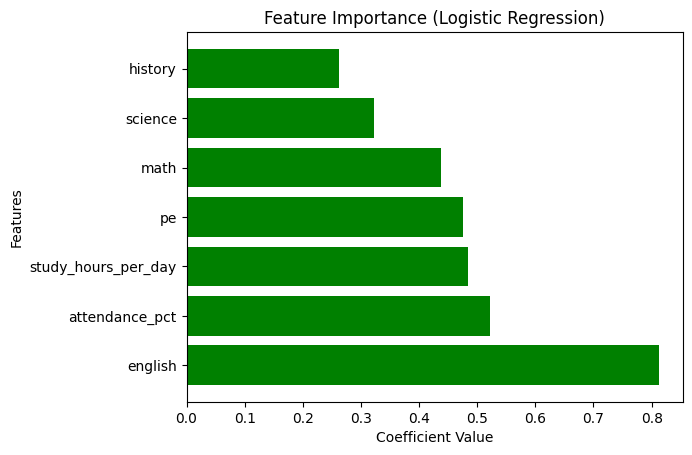

In [57]:
features = [f[0] for f in feature_importance]
values = [f[1] for f in feature_importance]

colors = ['green' if v > 0 else 'red' for v in values]

plt.figure()

plt.barh(features, values, color=colors)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.savefig("plot8_feature_importance.png")
plt.show()

In [58]:
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)
probability = model.predict_proba(new_scaled)

print("Prediction:", "Pass" if prediction[0]==1 else "Fail")
print("Probability:", probability)

Prediction: Pass
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
